# Crop Disease Detection
Custom CNN trained on the PlantVillage dataset to classify 38 plant disease classes.


## 1. Install & Import Libraries

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
from datetime import datetime
import os
import copy
import time
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.utils.data import DataLoader
from torch.utils.data.sampler import SubsetRandomSampler

from torchvision import datasets, transforms, models
import torchvision.transforms.functional as TF
from PIL import Image

from sklearn.metrics import confusion_matrix, classification_report

# Check device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Using device: cuda
GPU: Tesla T4


## 2. Dataset Path & Exploration

In [22]:
DATASET_PATH = '/kaggle/input/datasets/abdallahalidev/plantvillage-dataset/color'

classes = sorted(os.listdir(DATASET_PATH))
num_classes = len(classes)
print(f'Total classes found: {num_classes}')
print(f'\nClasses:')
for i, c in enumerate(classes):
    count = len(os.listdir(os.path.join(DATASET_PATH, c)))
    print(f'  [{i:2d}] {c} — {count} images')

Total classes found: 38

Classes:
  [ 0] Apple___Apple_scab — 630 images
  [ 1] Apple___Black_rot — 621 images
  [ 2] Apple___Cedar_apple_rust — 275 images
  [ 3] Apple___healthy — 1645 images
  [ 4] Blueberry___healthy — 1502 images
  [ 5] Cherry_(including_sour)___Powdery_mildew — 1052 images
  [ 6] Cherry_(including_sour)___healthy — 854 images
  [ 7] Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot — 513 images
  [ 8] Corn_(maize)___Common_rust_ — 1192 images
  [ 9] Corn_(maize)___Northern_Leaf_Blight — 985 images
  [10] Corn_(maize)___healthy — 1162 images
  [11] Grape___Black_rot — 1180 images
  [12] Grape___Esca_(Black_Measles) — 1383 images
  [13] Grape___Leaf_blight_(Isariopsis_Leaf_Spot) — 1076 images
  [14] Grape___healthy — 423 images
  [15] Orange___Haunglongbing_(Citrus_greening) — 5507 images
  [16] Peach___Bacterial_spot — 2297 images
  [17] Peach___healthy — 360 images
  [18] Pepper,_bell___Bacterial_spot — 997 images
  [19] Pepper,_bell___healthy — 1478 images
  [20

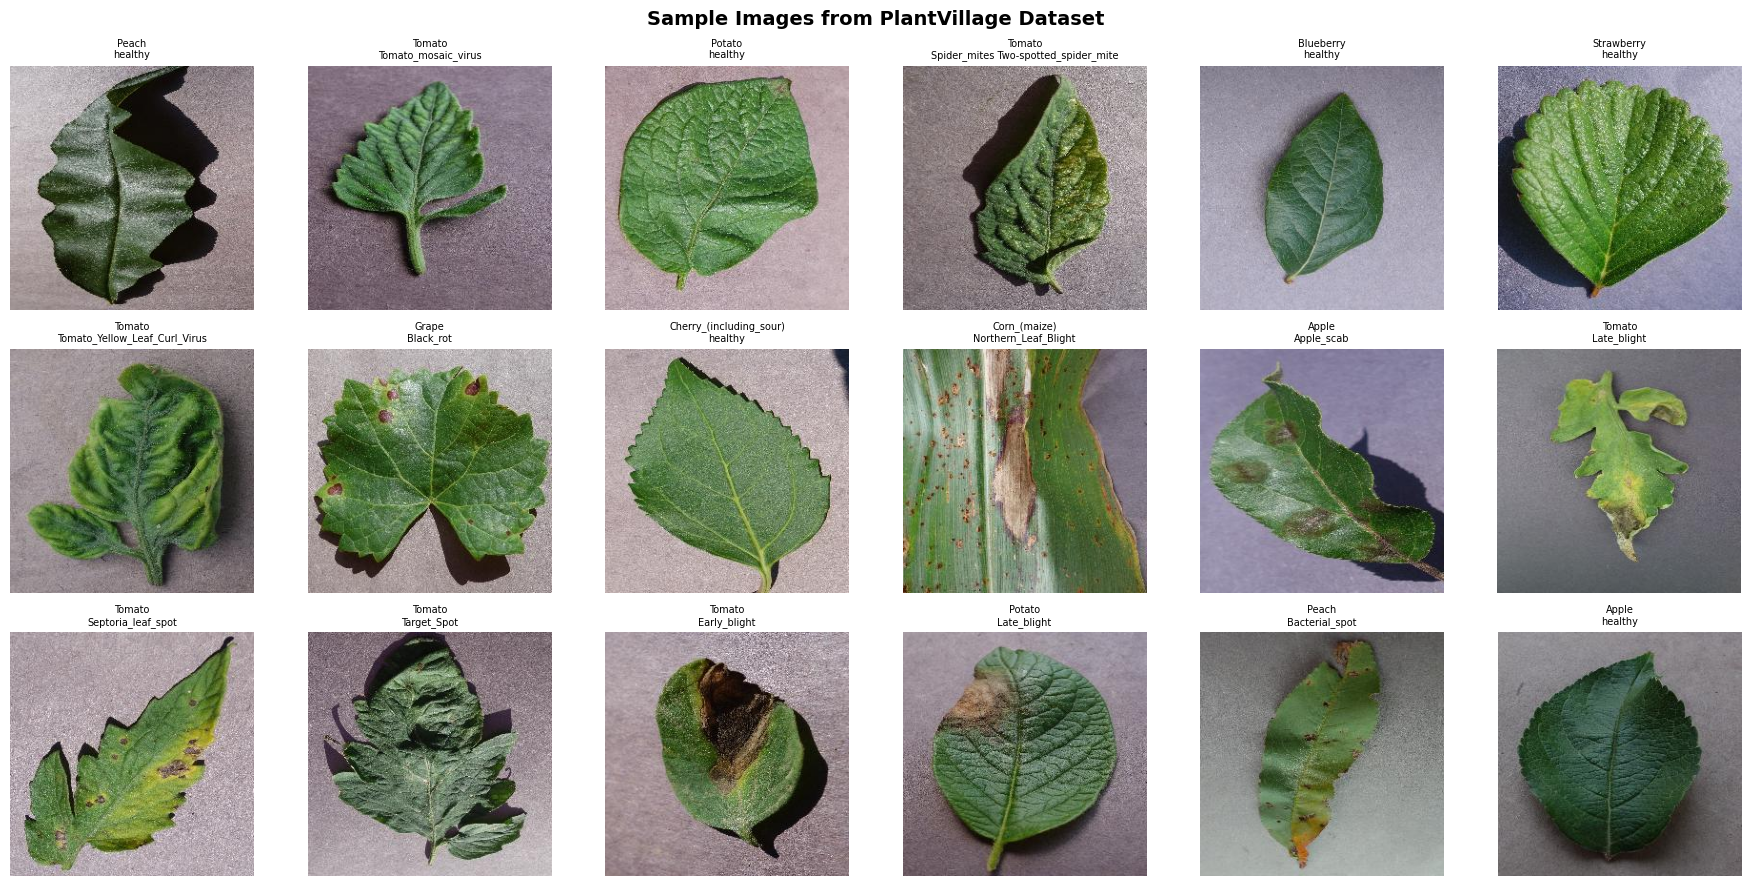

In [23]:
# Visualize sample images from different classes
fig, axes = plt.subplots(3, 6, figsize=(18, 9))
sample_classes = np.random.choice(classes, 18, replace=False)

for ax, cls in zip(axes.flatten(), sample_classes):
    cls_path = os.path.join(DATASET_PATH, cls)
    img_file = np.random.choice(os.listdir(cls_path))
    img = mpimg.imread(os.path.join(cls_path, img_file))
    ax.imshow(img)
    ax.set_title(cls.replace('___', '\n').replace('__', '\n'), fontsize=7)
    ax.axis('off')

plt.suptitle('Sample Images from PlantVillage Dataset', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 3. Data Preprocessing & Augmentation

In [24]:
IMG_SIZE = 224

train_transforms = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    # ImageNet normalization — critical for good accuracy
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

print('Transforms defined!')
print(f'Training: Resize → RandomCrop → Flip → Rotate → ColorJitter → Normalize')
print(f'Validation: Resize → CenterCrop → Normalize')

Transforms defined!
Training: Resize → RandomCrop → Flip → Rotate → ColorJitter → Normalize
Validation: Resize → CenterCrop → Normalize


In [25]:
full_dataset_train = datasets.ImageFolder(DATASET_PATH, transform=train_transforms)
full_dataset_val   = datasets.ImageFolder(DATASET_PATH, transform=val_transforms)

class_to_idx = full_dataset_train.class_to_idx
idx_to_class = {v: k for k, v in class_to_idx.items()}

print(f'Total images: {len(full_dataset_train)}')
print(f'Number of classes: {len(class_to_idx)}')

dataset_size = len(full_dataset_train)
indices = list(range(dataset_size))
np.random.seed(42)
np.random.shuffle(indices)

train_end = int(0.70 * dataset_size)
val_end   = int(0.85 * dataset_size)

train_indices = indices[:train_end]
val_indices   = indices[train_end:val_end]
test_indices  = indices[val_end:]

print(f'\nSplit:')
print(f'  Train : {len(train_indices)} images ({70}%)')
print(f'  Val   : {len(val_indices)} images ({15}%)')
print(f'  Test  : {len(test_indices)} images ({15}%)')

Total images: 54305
Number of classes: 38

Split:
  Train : 38013 images (70%)
  Val   : 8146 images (15%)
  Test  : 8146 images (15%)


In [26]:
BATCH_SIZE = 64

train_loader = DataLoader(
    full_dataset_train,
    batch_size=BATCH_SIZE,
    sampler=SubsetRandomSampler(train_indices),
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    full_dataset_val,
    batch_size=BATCH_SIZE,
    sampler=SubsetRandomSampler(val_indices),
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    full_dataset_val,
    batch_size=BATCH_SIZE,
    sampler=SubsetRandomSampler(test_indices),
    num_workers=2,
    pin_memory=True
)

print(f'Batch size: {BATCH_SIZE}')
print(f'Train batches: {len(train_loader)}')
print(f'Val batches  : {len(val_loader)}')
print(f'Test batches : {len(test_loader)}')

Batch size: 64
Train batches: 594
Val batches  : 128
Test batches : 128


## 4. Model Architecture 

In [27]:

class ResidualBlock(nn.Module):

    def __init__(self, in_channels, out_channels, stride=1):
        super(ResidualBlock, self).__init__()

        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3,
                                stride=stride, padding=1, bias=False)
        self.bn1   = nn.BatchNorm2d(out_channels)

        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3,
                                stride=1, padding=1, bias=False)
        self.bn2   = nn.BatchNorm2d(out_channels)

        self.skip = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.skip = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1,
                          stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        identity = self.skip(x)         
        out = self.relu(self.bn1(self.conv1(x)))   
        out = self.bn2(self.conv2(out))             
        out = self.relu(out + identity)  
        return out


class CustomCNN(nn.Module):
   
    def __init__(self, num_classes=39):
        super(CustomCNN, self).__init__()

        self.initial = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        )

        self.stage1 = nn.Sequential(
            ResidualBlock(64, 64),
            ResidualBlock(64, 64)
        )

        self.stage2 = nn.Sequential(
            ResidualBlock(64, 128, stride=2),
            ResidualBlock(128, 128)
        )

        self.stage3 = nn.Sequential(
            ResidualBlock(128, 256, stride=2),
            ResidualBlock(256, 256)
        )

        self.stage4 = nn.Sequential(
            ResidualBlock(256, 512, stride=2),
            ResidualBlock(512, 512)
        )

        self.gap = nn.AdaptiveAvgPool2d((1, 1))

        self.classifier = nn.Sequential(
            nn.Dropout(p=0.4),
            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.initial(x)   # (B, 64, 56, 56)
        x = self.stage1(x)    # (B, 64, 56, 56)
        x = self.stage2(x)    # (B, 128, 28, 28)
        x = self.stage3(x)    # (B, 256, 14, 14)
        x = self.stage4(x)    # (B, 512, 7, 7)
        x = self.gap(x)       # (B, 512, 1, 1)
        x = x.view(x.size(0), -1)  # (B, 512)
        x = self.classifier(x)     # (B, num_classes)
        return x


model = CustomCNN(num_classes=num_classes).to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Model Architecture: Custom CNN with Residual Connections')
print(f'Total parameters    : {total_params:,}')
print(f'Trainable parameters: {trainable_params:,}')
print(f'\nModel ready on: {device}')

Model Architecture: Custom CNN with Residual Connections
Total parameters    : 11,317,606
Trainable parameters: 11,317,606

Model ready on: cuda


In [28]:
dummy = torch.randn(2, 3, 224, 224).to(device)
out = model(dummy)
print(f'Input shape : {dummy.shape}')
print(f'Output shape: {out.shape}  (batch_size, num_classes)')
print('Forward pass OK!')

Input shape : torch.Size([2, 3, 224, 224])
Output shape: torch.Size([2, 38])  (batch_size, num_classes)
Forward pass OK!


## 5. Training Setup

In [29]:
# Loss function
criterion = nn.CrossEntropyLoss()

# Optimizer
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

# LR Scheduler remove verbose=True
scheduler = ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=2,
    min_lr=1e-6
)

print('Training setup ready:')
print(f'  Loss     : CrossEntropyLoss')
print(f'  Optimizer: Adam (lr=0.001, weight_decay=1e-4)')
print(f'  Scheduler: ReduceLROnPlateau (patience=2, factor=0.5)')

Training setup ready:
  Loss     : CrossEntropyLoss
  Optimizer: Adam (lr=0.001, weight_decay=1e-4)
  Scheduler: ReduceLROnPlateau (patience=2, factor=0.5)


## 6. Training Loop

In [30]:
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for inputs, targets in loader:
        inputs, targets = inputs.to(device), targets.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == targets).sum().item()
        total += targets.size(0)

    return total_loss / total, correct / total


def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0

    with torch.no_grad():
        for inputs, targets in loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, targets)

            total_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == targets).sum().item()
            total += targets.size(0)

    return total_loss / total, correct / total


print('Training functions ready!')

Training functions ready!


In [31]:
EPOCHS = 20
PATIENCE = 5  

history = {
    'train_loss': [], 'val_loss': [],
    'train_acc':  [], 'val_acc': []
}

best_val_loss = float('inf')
best_model_weights = None
patience_counter = 0

print(f'Starting training for {EPOCHS} epochs...\n')
print(f'{"Epoch":>6} | {"Train Loss":>10} | {"Train Acc":>9} | {"Val Loss":>8} | {"Val Acc":>7} | {"Time":>6}')
print('-' * 62)

for epoch in range(1, EPOCHS + 1):
    t0 = time.time()

    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer)
    val_loss,   val_acc   = evaluate(model, val_loader, criterion)

    scheduler.step(val_loss)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    elapsed = time.time() - t0
    print(f'{epoch:6d} | {train_loss:10.4f} | {train_acc*100:8.2f}% | {val_loss:8.4f} | {val_acc*100:6.2f}% | {elapsed:5.0f}s')

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_weights = copy.deepcopy(model.state_dict())
        torch.save(best_model_weights, 'plant_disease_model_v2.pt')
        print(f'         ✓ Best model saved (val_loss: {best_val_loss:.4f})')
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f'\nEarly stopping at epoch {epoch} (no improvement for {PATIENCE} epochs)')
            break

model.load_state_dict(best_model_weights)
print(f'\nTraining complete! Best val loss: {best_val_loss:.4f}')

Starting training for 20 epochs...

 Epoch | Train Loss | Train Acc | Val Loss | Val Acc |   Time
--------------------------------------------------------------
     1 |     2.2535 |    37.31% |   1.3992 |  56.91% |   323s
         ✓ Best model saved (val_loss: 1.3992)
     2 |     1.4945 |    54.72% |   1.0564 |  67.20% |   192s
         ✓ Best model saved (val_loss: 1.0564)
     3 |     1.1987 |    63.54% |   1.1442 |  66.07% |   194s
     4 |     0.9834 |    68.98% |   0.7115 |  77.17% |   194s
         ✓ Best model saved (val_loss: 0.7115)
     5 |     0.8096 |    74.62% |   0.5775 |  81.79% |   191s
         ✓ Best model saved (val_loss: 0.5775)
     6 |     0.6833 |    78.43% |   0.6238 |  80.30% |   192s
     7 |     0.5714 |    81.79% |   0.3425 |  88.41% |   192s
         ✓ Best model saved (val_loss: 0.3425)
     8 |     0.4871 |    84.47% |   0.2478 |  91.69% |   197s
         ✓ Best model saved (val_loss: 0.2478)
     9 |     0.4281 |    86.37% |   0.2674 |  91.16% |   191s

## 7. Training Curves

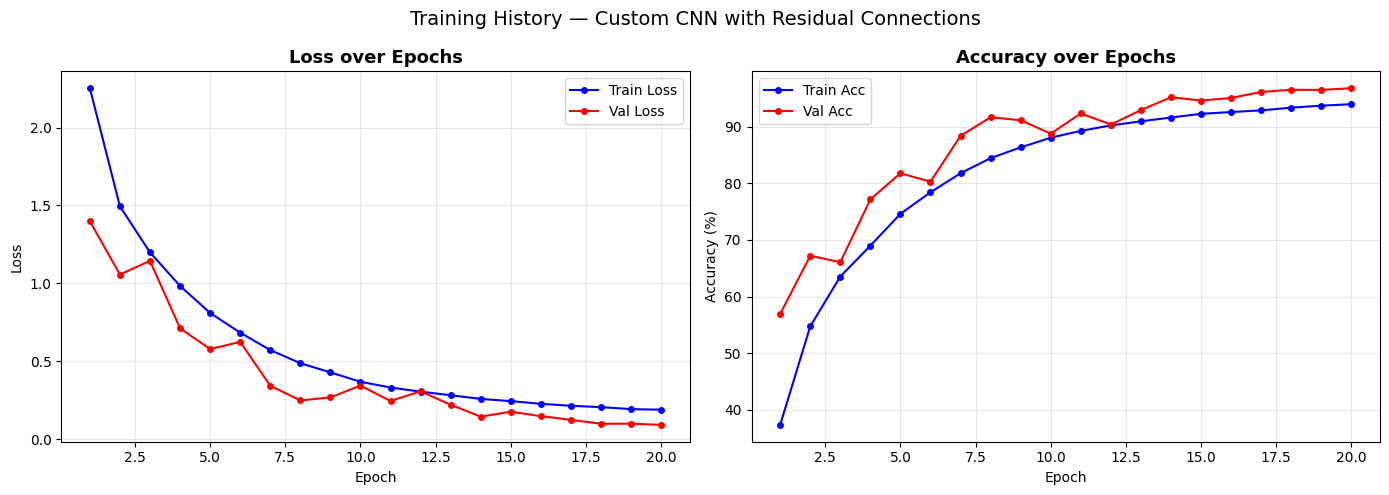

In [32]:
epochs_ran = len(history['train_loss'])
x = range(1, epochs_ran + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss plot
ax1.plot(x, history['train_loss'], 'b-o', label='Train Loss', markersize=4)
ax1.plot(x, history['val_loss'],   'r-o', label='Val Loss',   markersize=4)
ax1.set_title('Loss over Epochs', fontsize=13, fontweight='bold')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Accuracy plot
ax2.plot(x, [a*100 for a in history['train_acc']], 'b-o', label='Train Acc', markersize=4)
ax2.plot(x, [a*100 for a in history['val_acc']],   'r-o', label='Val Acc',   markersize=4)
ax2.set_title('Accuracy over Epochs', fontsize=13, fontweight='bold')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle('Training History — Custom CNN with Residual Connections', fontsize=14)
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Evaluation on Test Set

In [33]:
train_loss_f, train_acc_f = evaluate(model, train_loader, criterion)
val_loss_f,   val_acc_f   = evaluate(model, val_loader,   criterion)
test_loss_f,  test_acc_f  = evaluate(model, test_loader,  criterion)

print('=' * 45)
print(f'  FINAL RESULTS')
print('=' * 45)
print(f'  Train Accuracy : {train_acc_f*100:.2f}%')
print(f'  Val   Accuracy : {val_acc_f*100:.2f}%')
print(f'  Test  Accuracy : {test_acc_f*100:.2f}%')
print('=' * 45)

  FINAL RESULTS
  Train Accuracy : 95.74%
  Val   Accuracy : 96.83%
  Test  Accuracy : 97.09%


In [34]:
all_preds, all_labels = [], []

model.eval()
with torch.no_grad():
    for inputs, targets in test_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(targets.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

print('Predictions collected!')
print(f'Test samples: {len(all_preds)}')

Predictions collected!
Test samples: 8146


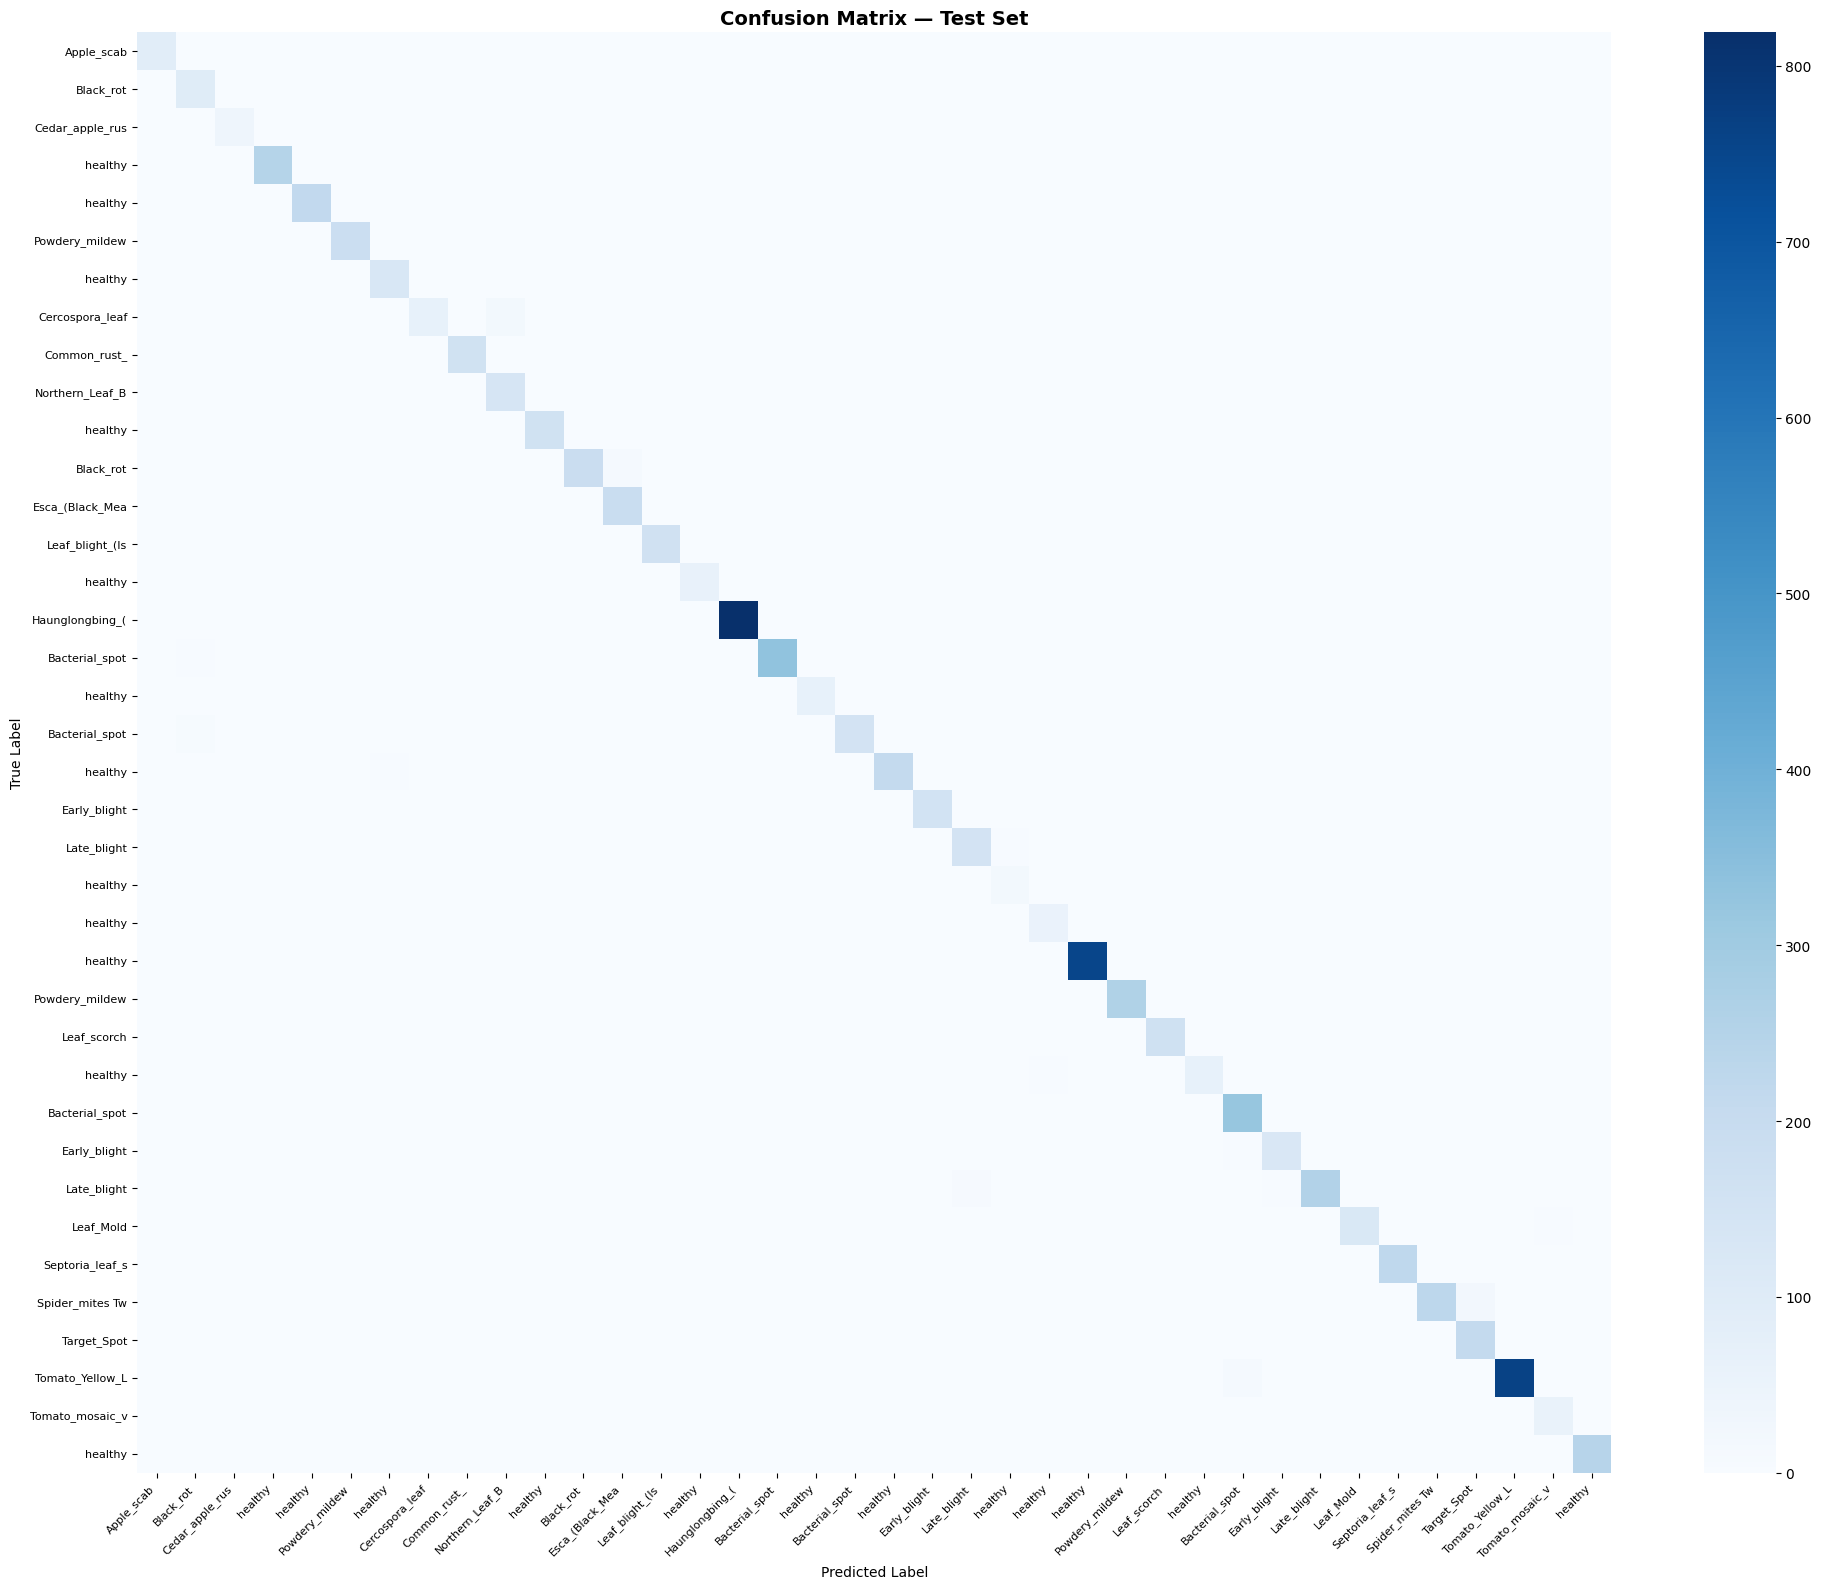

In [35]:
# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(20, 16))
sns.heatmap(
    cm, annot=False, fmt='d', cmap='Blues',
    xticklabels=[c.split('___')[-1][:15] for c in classes],
    yticklabels=[c.split('___')[-1][:15] for c in classes]
)
plt.title('Confusion Matrix — Test Set', fontsize=14, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

In [36]:
per_class_acc = cm.diagonal() / cm.sum(axis=1)

print(f'\nPer-class Accuracy:')
print(f'{"Class":<50} {"Accuracy":>8}')
print('-' * 60)
for cls, acc in sorted(zip(classes, per_class_acc), key=lambda x: x[1]):
    bar = '-' * int(acc * 20)
    print(f'{cls:<50} {acc*100:6.1f}%  {bar}')


Per-class Accuracy:
Class                                              Accuracy
------------------------------------------------------------
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot   74.4%  ██████████████
Tomato___Leaf_Mold                                   86.7%  █████████████████
Tomato___Spider_mites Two-spotted_spider_mite        88.7%  █████████████████
Tomato___Early_blight                                90.7%  ██████████████████
Tomato___Late_blight                                 90.8%  ██████████████████
Pepper,_bell___Bacterial_spot                        91.1%  ██████████████████
Potato___healthy                                     91.3%  ██████████████████
Strawberry___healthy                                 91.4%  ██████████████████
Grape___Black_rot                                    93.1%  ██████████████████
Tomato___Septoria_leaf_spot                          94.1%  ██████████████████
Potato___Late_blight                                 94.4%  ██████████████

## Inference

In [37]:

def predict(image_path, model, idx_to_class, top_k=3):
    transform = transforms.Compose([
        transforms.Resize((256, 256)),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225])
    ])

    image = Image.open(image_path).convert('RGB')  # handles RGBA PNGs too
    input_tensor = transform(image).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        output = model(input_tensor)
        probabilities = F.softmax(output, dim=1)[0]

    top_probs, top_indices = torch.topk(probabilities, top_k)

    results = []
    for prob, idx in zip(top_probs, top_indices):
        results.append({
            'class': idx_to_class[idx.item()],
            'confidence': prob.item() * 100
        })

    return results


sample_cls  = classes[0]
sample_dir  = os.path.join(DATASET_PATH, sample_cls)
sample_img  = os.path.join(sample_dir, os.listdir(sample_dir)[0])

results = predict(sample_img, model, idx_to_class)

print(f'Test image : {sample_img}')
print(f'True label : {sample_cls}')
print(f'\nTop 3 Predictions:')
for i, r in enumerate(results, 1):
    print(f'  {i}. {r["class"]:50s} {r["confidence"]:6.2f}%')

Test image : /kaggle/input/datasets/abdallahalidev/plantvillage-dataset/color/Apple___Apple_scab/5a178d63-372d-48c4-adb8-d616130ba3f0___FREC_Scab 3104.JPG
True label : Apple___Apple_scab

Top 3 Predictions:
  1. Apple___Apple_scab                                  99.80%
  2. Squash___Powdery_mildew                              0.06%
  3. Apple___Black_rot                                    0.05%


## 10. Save Model & Class Mapping

In [38]:
torch.save(model.state_dict(), 'plant_disease_model_v2.pt')
print('Model saved: plant_disease_model_v2.pt')

import json
with open('class_mapping.json', 'w') as f:
    json.dump(idx_to_class, f, indent=2)
print('Class mapping saved: class_mapping.json')

print('\nFiles saved to /kaggle/working/:')
for f in os.listdir('/kaggle/working'):
    size = os.path.getsize(f'/kaggle/working/{f}') / (1024*1024)
    print(f'  {f} ({size:.1f} MB)')

Model saved: plant_disease_model_v2.pt
Class mapping saved: class_mapping.json

Files saved to /kaggle/working/:
  confusion_matrix.png (0.2 MB)
  training_curves.png (0.1 MB)
  .virtual_documents (0.0 MB)
  plant_disease_model_v2.pt (43.3 MB)
  class_mapping.json (0.0 MB)
